# Code for reproducing Figure S2 plots for the D40-100 data
## This notebooks depend on first generating the processed and clustered data

last updated: 20241202

## Import data and functions

In [3]:
import scanpy as sc
import pandas as pd
import anndata
import os
import re
import numpy as np
import scipy
import seaborn
import bbknn
import matplotlib
import matplotlib.pyplot as plt


In [4]:
# set a path to your working directory
directory='/Set/your/path/'

# load .h5ad with processed data 
adata = sc.read_h5ad(directory+'/Written_files/D40-100_GEX_processed-clustered.h5ad')

print(adata)

AnnData object with n_obs × n_vars = 105777 × 51861
    obs: 'batch_name', 'demux_type', 'assignment', 'CHIR_conc', 'individual', 'individual_type', 'individual_llr', 'species', 'pool_type', 'time_point', 'experiment', 'day_10x', 'lane', 'n_genes', 'percent_mito', 'percent_ribo', 'n_counts', 'leiden'
    var: 'gene_ids-D100_M_0-4_Chimp', 'feature_types-D100_M_0-4_Chimp', 'genome-D100_M_0-4_Chimp', 'gene_ids-D100_M_0-4_Human', 'feature_types-D100_M_0-4_Human', 'genome-D100_M_0-4_Human', 'gene_ids-D100_M_0-4_Rhesus', 'feature_types-D100_M_0-4_Rhesus', 'genome-D100_M_0-4_Rhesus', 'gene_ids-D100_M_0-5_Chimp', 'feature_types-D100_M_0-5_Chimp', 'genome-D100_M_0-5_Chimp', 'gene_ids-D100_M_0-5_Human', 'feature_types-D100_M_0-5_Human', 'genome-D100_M_0-5_Human', 'gene_ids-D100_M_0-5_Rhesus', 'feature_types-D100_M_0-5_Rhesus', 'genome-D100_M_0-5_Rhesus', 'gene_ids-D100_M_0-6_Chimp', 'feature_types-D100_M_0-6_Chimp', 'genome-D100_M_0-6_Chimp', 'gene_ids-D100_M_0-6_Human', 'feature_types-D100_M_0-

# Figure panel S2E (D40-100)

Proportions of individuals in chimpanzee intraspecies pools

In [11]:
# Create obs species_individual
species_individual = pd.Categorical(adata.obs['species'].astype(str) + ('_') + adata.obs['individual'].astype(str))
adata.obs['species_individual'] = species_individual

# Create obs experiment_timepoint
experiment_timepoint = pd.Categorical(adata.obs['experiment'].astype(str) + ('_') + adata.obs['time_point'].astype(str))
adata.obs['experiment_timepoint'] = experiment_timepoint

# only plot cells with assigned identity
adata_D40_100_proportion = adata[~adata.obs['species_individual'].isin(['chimp_nan','human_nan', 'macaque_nan'])]

# Create subsets of data to plot in Figure S2E-G
adata_intraspecies = adata_D40_100_proportion[adata_D40_100_proportion.obs['pool_type'].isin(['Intraspecies'])]
adata_interspecies = adata_D40_100_proportion[adata_D40_100_proportion.obs['pool_type'].isin(['Interspecies'])]
adata_intra_chimp = adata_intraspecies[adata_intraspecies.obs['species'].isin(['chimp'])]
adata_intra_human = adata_intraspecies[adata_intraspecies.obs['species'].isin(['human'])]

# Set color scheme
custom_colors = {
    'chimp_C3624': 'cornflowerblue',
    'chimp_C3651': 'royalblue',
    'chimp_C4933': 'navy',
    'chimp_C8861': 'blue',
    'chimp_C40210': 'mediumblue',
    'chimp_C40300': 'dodgerblue',
    'chimp_C40670': 'lightsteelblue',
    'human_H9': 'orange',
    'human_H20961': 'darkkhaki',
    'human_H21194': 'goldenrod',
    'human_H21792': 'navajowhite',
    'human_H23555': 'darkorange',
    'human_H28126': 'khaki',
    'human_H28834': 'yellow',
    'human_H29089': 'gold',
    'macaque_ZG15-M11-10': 'purple',
    'macaque_ES_Lyon': 'mediumvioletred',
    'macaque_ZH26-HS16': 'magenta',
    'orangutan_O11045-4593': 'sienna',
}

<Figure size 432x288 with 0 Axes>

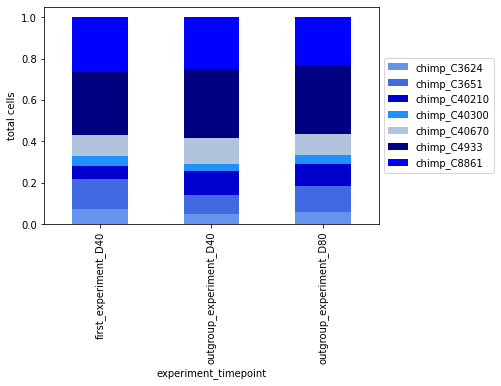

In [12]:
f = plt.figure()
df_plot = adata_intra_chimp.obs.groupby(['species_individual', 'experiment_timepoint']).size().reset_index().pivot(columns='species_individual', index='experiment_timepoint', values=0).apply(lambda g: g / g.sum(), 1)

# Extract individual names from the columns
individuals = df_plot.columns

# Create a list of colors based on the custom_colors dictionary
colors = [custom_colors.get(individual, None) for individual in individuals]

# Filter out None values (default_color) from the list
colors = [color for color in colors if color is not None]

ax = df_plot.plot(kind='bar', stacked=True, color=colors)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.ylabel('total cells')

plt.show()

# Figure panel S2F (D40-100)

Proportions of individuals in human intraspecies pools

<Figure size 432x288 with 0 Axes>

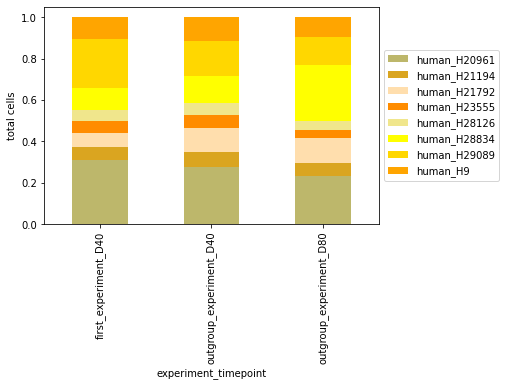

In [13]:
f = plt.figure()
df_plot = adata_intra_human.obs.groupby(['species_individual', 'experiment_timepoint']).size().reset_index().pivot(columns='species_individual', index='experiment_timepoint', values=0).apply(lambda g: g / g.sum(), 1)

# Extract individual names from the columns
individuals = df_plot.columns

# Create a list of colors based on the custom_colors dictionary
colors = [custom_colors.get(individual, None) for individual in individuals]

# Filter out None values (default_color) from the list
colors = [color for color in colors if color is not None]

ax = df_plot.plot(kind='bar', stacked=True, color=colors)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.ylabel('total cells')

plt.show()

# Figure panel S2G (D40-100)

Proportions of individuals in interspecies pools

<Figure size 432x288 with 0 Axes>

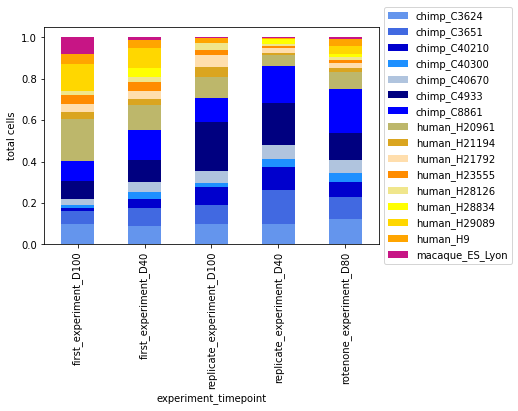

In [14]:
f = plt.figure()
df_plot = adata_interspecies.obs.groupby(['species_individual', 'experiment_timepoint']).size().reset_index().pivot(columns='species_individual', index='experiment_timepoint', values=0).apply(lambda g: g / g.sum(),1)

# Extract individual names from the columns
individuals = df_plot.columns

# Create a list of colors based on the custom_colors dictionary
colors = [custom_colors.get(individual, None) for individual in individuals]

# Filter out None values (default_color) from the list
colors = [color for color in colors if color is not None]

ax = df_plot.plot(kind='bar', stacked=True, color=colors)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.ylabel('total cells')

plt.show()

# Figure panel S2R

UMAPs of D40-100 cells colored by leiden group

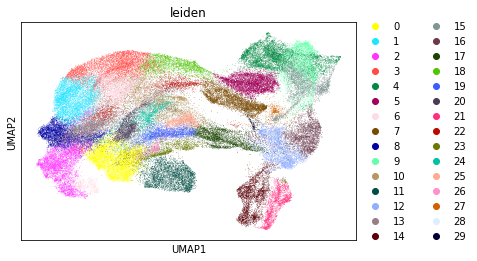

In [15]:
sc.pl.umap(adata, color=['leiden'], save='_D40-100_leiden.png')

# Figure panel S2S

Bar chart showing the number of cells per species for each leiden cluster.

Text(0, 0.5, 'cell number')

<Figure size 432x288 with 0 Axes>

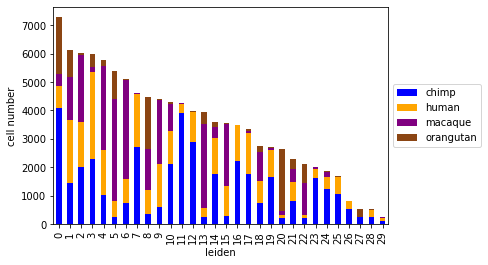

In [17]:
adata.uns['species_colors'] = ['blue','orange', 'purple','saddlebrown']
species_colors = adata.uns["species_colors"] 

f = plt.figure()
df_plot = adata.obs.groupby(['leiden', 'species']).size().reset_index().pivot(columns='species', index='leiden', values=0)
ax = df_plot.plot(kind='bar',  color=species_colors, legend=False,stacked=True)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.ylabel('cell number')

# Figure panel S2T

UMAPs of D40-100 cells, colored by scaled and normalized expression of neural stage and state specific genes. 

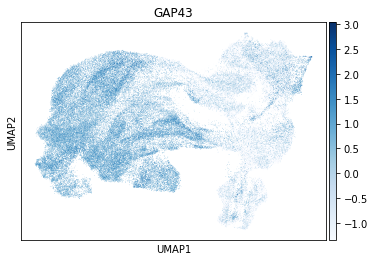

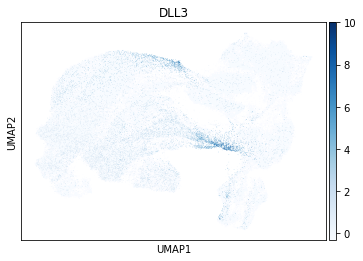

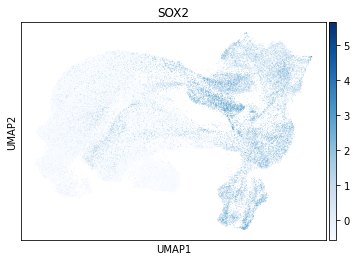

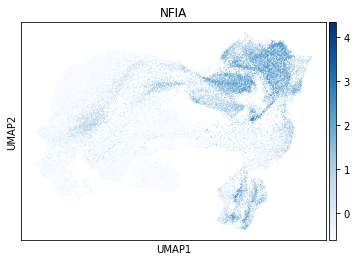

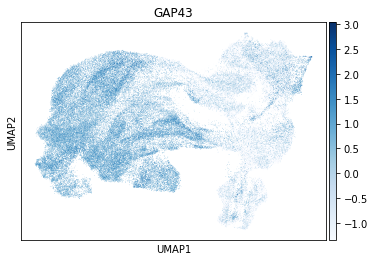

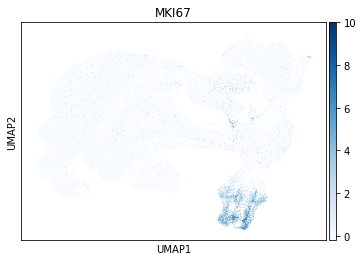

In [18]:
# color UMAP based on genes of interest
sc.pl.umap(adata, color=['GAP43'], use_raw=False, color_map=matplotlib.cm.Blues, 
           save='_D40-100_GAP43.png')
sc.pl.umap(adata, color=['DLL3'], use_raw=False, color_map=matplotlib.cm.Blues, 
           save='_D40-100_DLL3.png')
sc.pl.umap(adata, color=['SOX2'], use_raw=False, color_map=matplotlib.cm.Blues, 
           save='_D40-100_SOX2.png')
sc.pl.umap(adata, color=['NFIA'], use_raw=False, color_map=matplotlib.cm.Blues, 
           save='_D40-100_NFIA.png')
sc.pl.umap(adata, color=['GAP43'], use_raw=False, color_map=matplotlib.cm.Blues, 
           save='_D40-100_GAP43.png')
sc.pl.umap(adata, color=['MKI67'], use_raw=False, color_map=matplotlib.cm.Blues, 
           save='_D40-100_MKI67.png',)

# Figure panel S2U

UMAPs of D40-100 cells, colored by scaled and normalized expression of neuronal subtype markers in human.

In [19]:
# List genes of interest to plot
subtype_genes=['LMX1A','NR4A2','TH','TMCC3','GAD1','SLC17A6','LHX1','LHX9','ONECUT1' ]

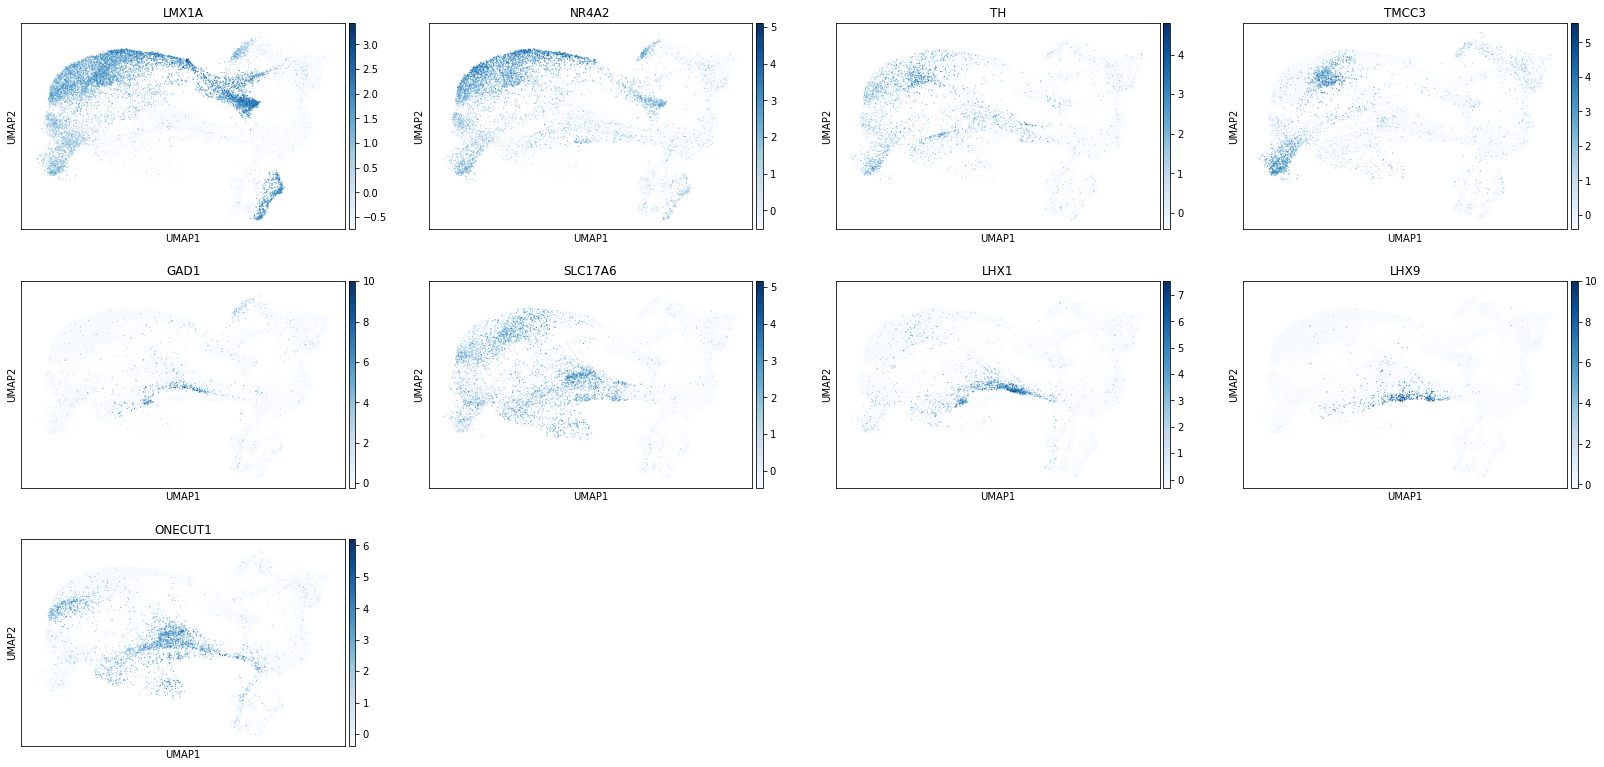

In [20]:
# color human cells of UMAP by genes of interest
adata_human = adata.obs['species'].str.contains('human')
sc.pl.umap(adata[adata_human,:],color=subtype_genes, use_raw=False,  
    palette="Set2", color_map=matplotlib.cm.Blues)

# Figure panel S2V

UMAPs of D40-100 cells, colored by scaled and normalized expression of neuronal subtype markers in chimpanzee.

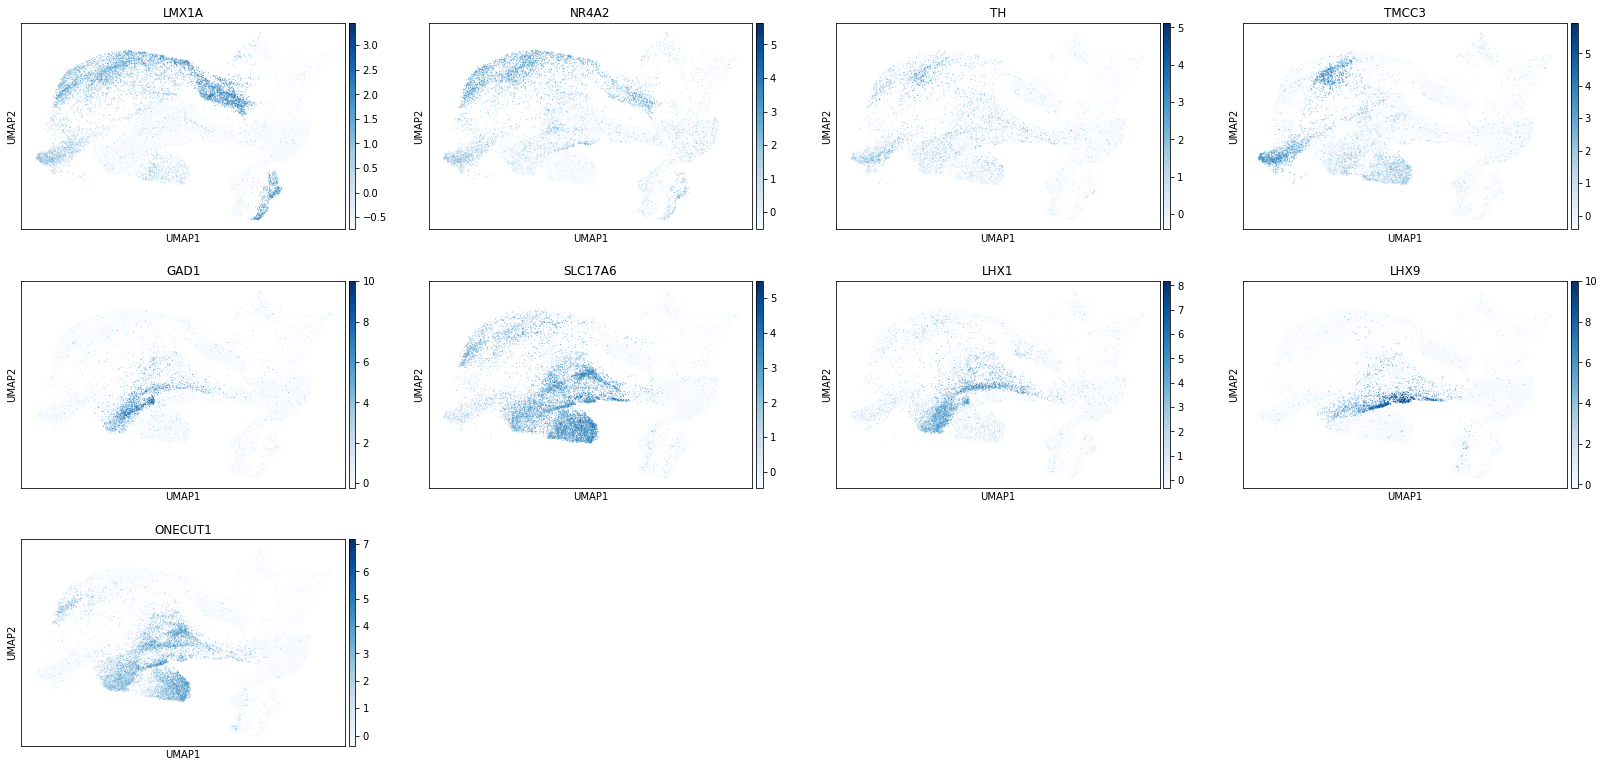

In [21]:
# color chimpanzee cells of UMAP by genes of interest
adata_chimp = adata.obs['species'].str.contains('chimp')
sc.pl.umap(adata[adata_chimp,:],color=subtype_genes, use_raw=False,  
    palette="Set2", color_map=matplotlib.cm.Blues)

# Figure panel S2W

UMAPs of D40-100 cells, colored by scaled and normalized expression of neuronal subtype markers in Orangutan.

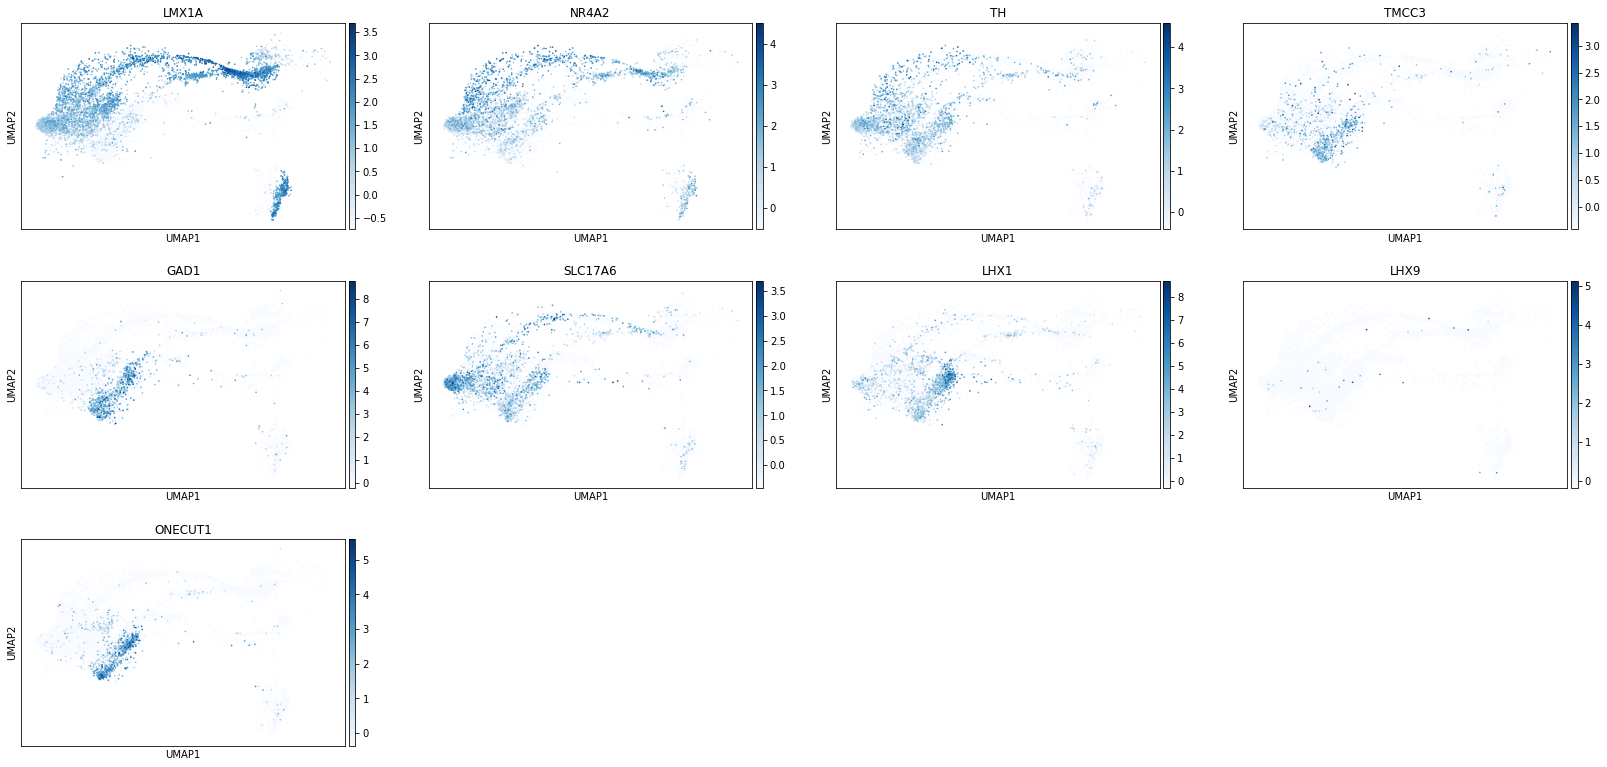

In [22]:
# color orangutan cells of UMAP by genes of interest
adata_orang = adata.obs['species'].str.contains('orang')
sc.pl.umap(adata[adata_orang,:],color=subtype_genes, use_raw=False,  
    palette="Set2", color_map=matplotlib.cm.Blues)

# Figure panel S2X

UMAPs of D40-100 cells, colored by scaled and normalized expression of neuronal subtype markers in Macaque.

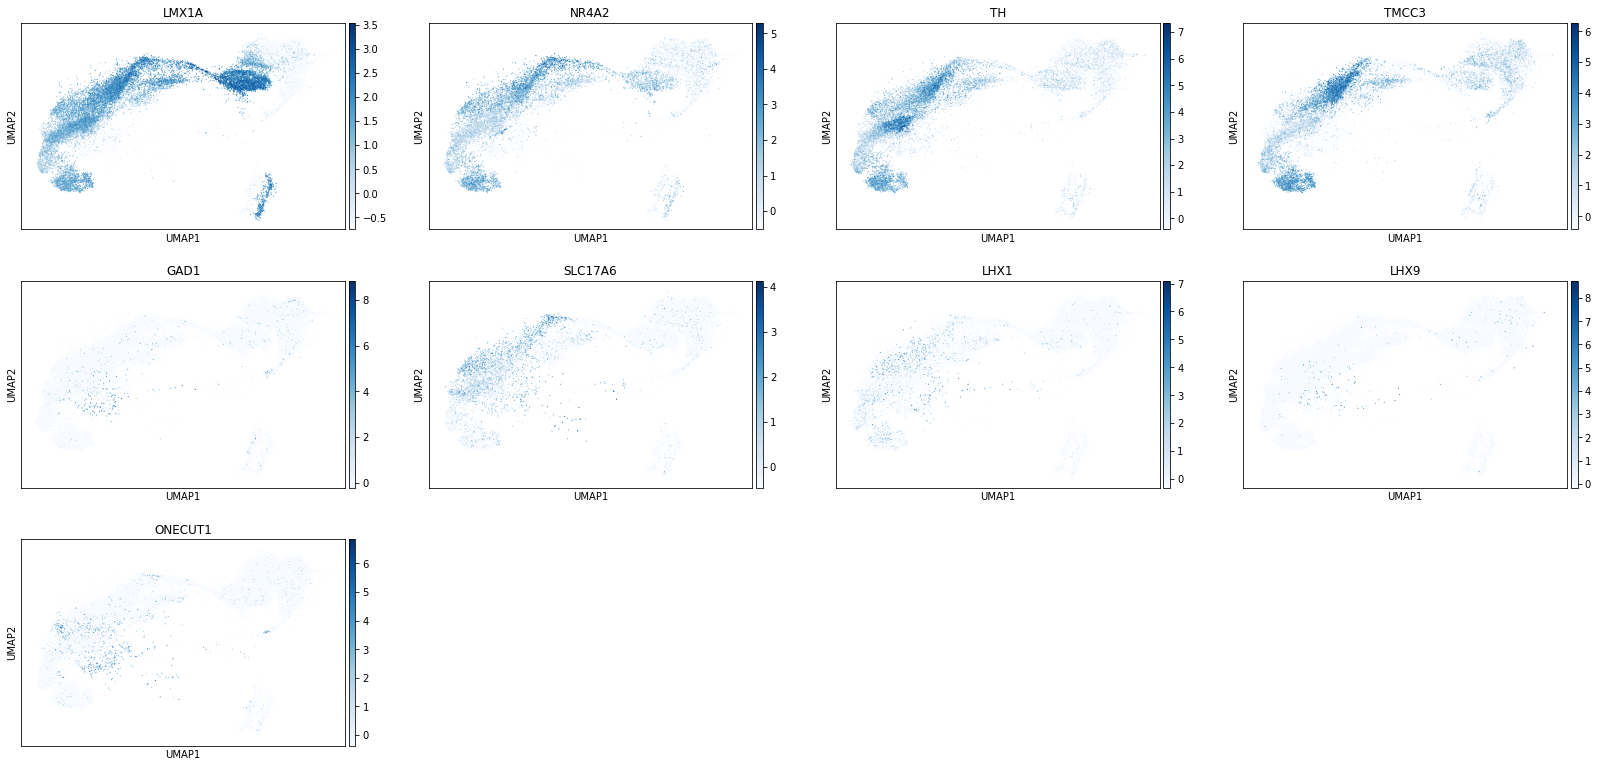

In [23]:
# color macaque cells of UMAP by genes of interest
adata_macaque = adata.obs['species'].str.contains('macaque')
sc.pl.umap(adata[adata_macaque,:],color=subtype_genes, use_raw=False,  
    palette="Set2", color_map=matplotlib.cm.Blues)